# 05 — Appendix per-cell grid

Single composite `09-cell-grid.png` (the thesis float `fig:appendix-cell-grid` expects ONE image, `width=\textwidth`, **not** paginated files): one minimum-wall-clock panel per (workload × tier).

**Cost-rates table (`08-cost-rates.tex`) is FLAGGED, not produced** — unit prices already live in the methods chapter as `tab:cost-model-unit-prices`, so per the brief it is skipped.

In [1]:
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
from src.plotting.style import StyleConfig
from src.analysis.tables import build_cost_summary
from src.analysis import thesis_compute as tc
from src.plotting import thesis_figures as tf

style = StyleConfig(); style.apply_rcparams()
CACHE = os.environ.get("DOPPA_CACHE", "cache/bench-cache.duckdb")
RUN_ID = "2026-05-26-OY0CN3"
FIG = Path("figures")
RQ1_W = ["point-in-polygon-lookup", "knn-search", "bbox-filtering"]

experiments, samples_df, metadata_df, costs_df, successful = tc.load_all(
    CACHE, "../doppa/benchmarks.yml", RUN_ID)
cost_summary = build_cost_summary(costs_df)
cells = [(w, t) for w in RQ1_W for t in ["small", "large"]] + \
        [("national-scale-spatial-join", t) for t in ["small", "medium", "large"]]
allcfg = ["duckdb", "postgis", "local", "databricks-broadcast-8-nodes"]

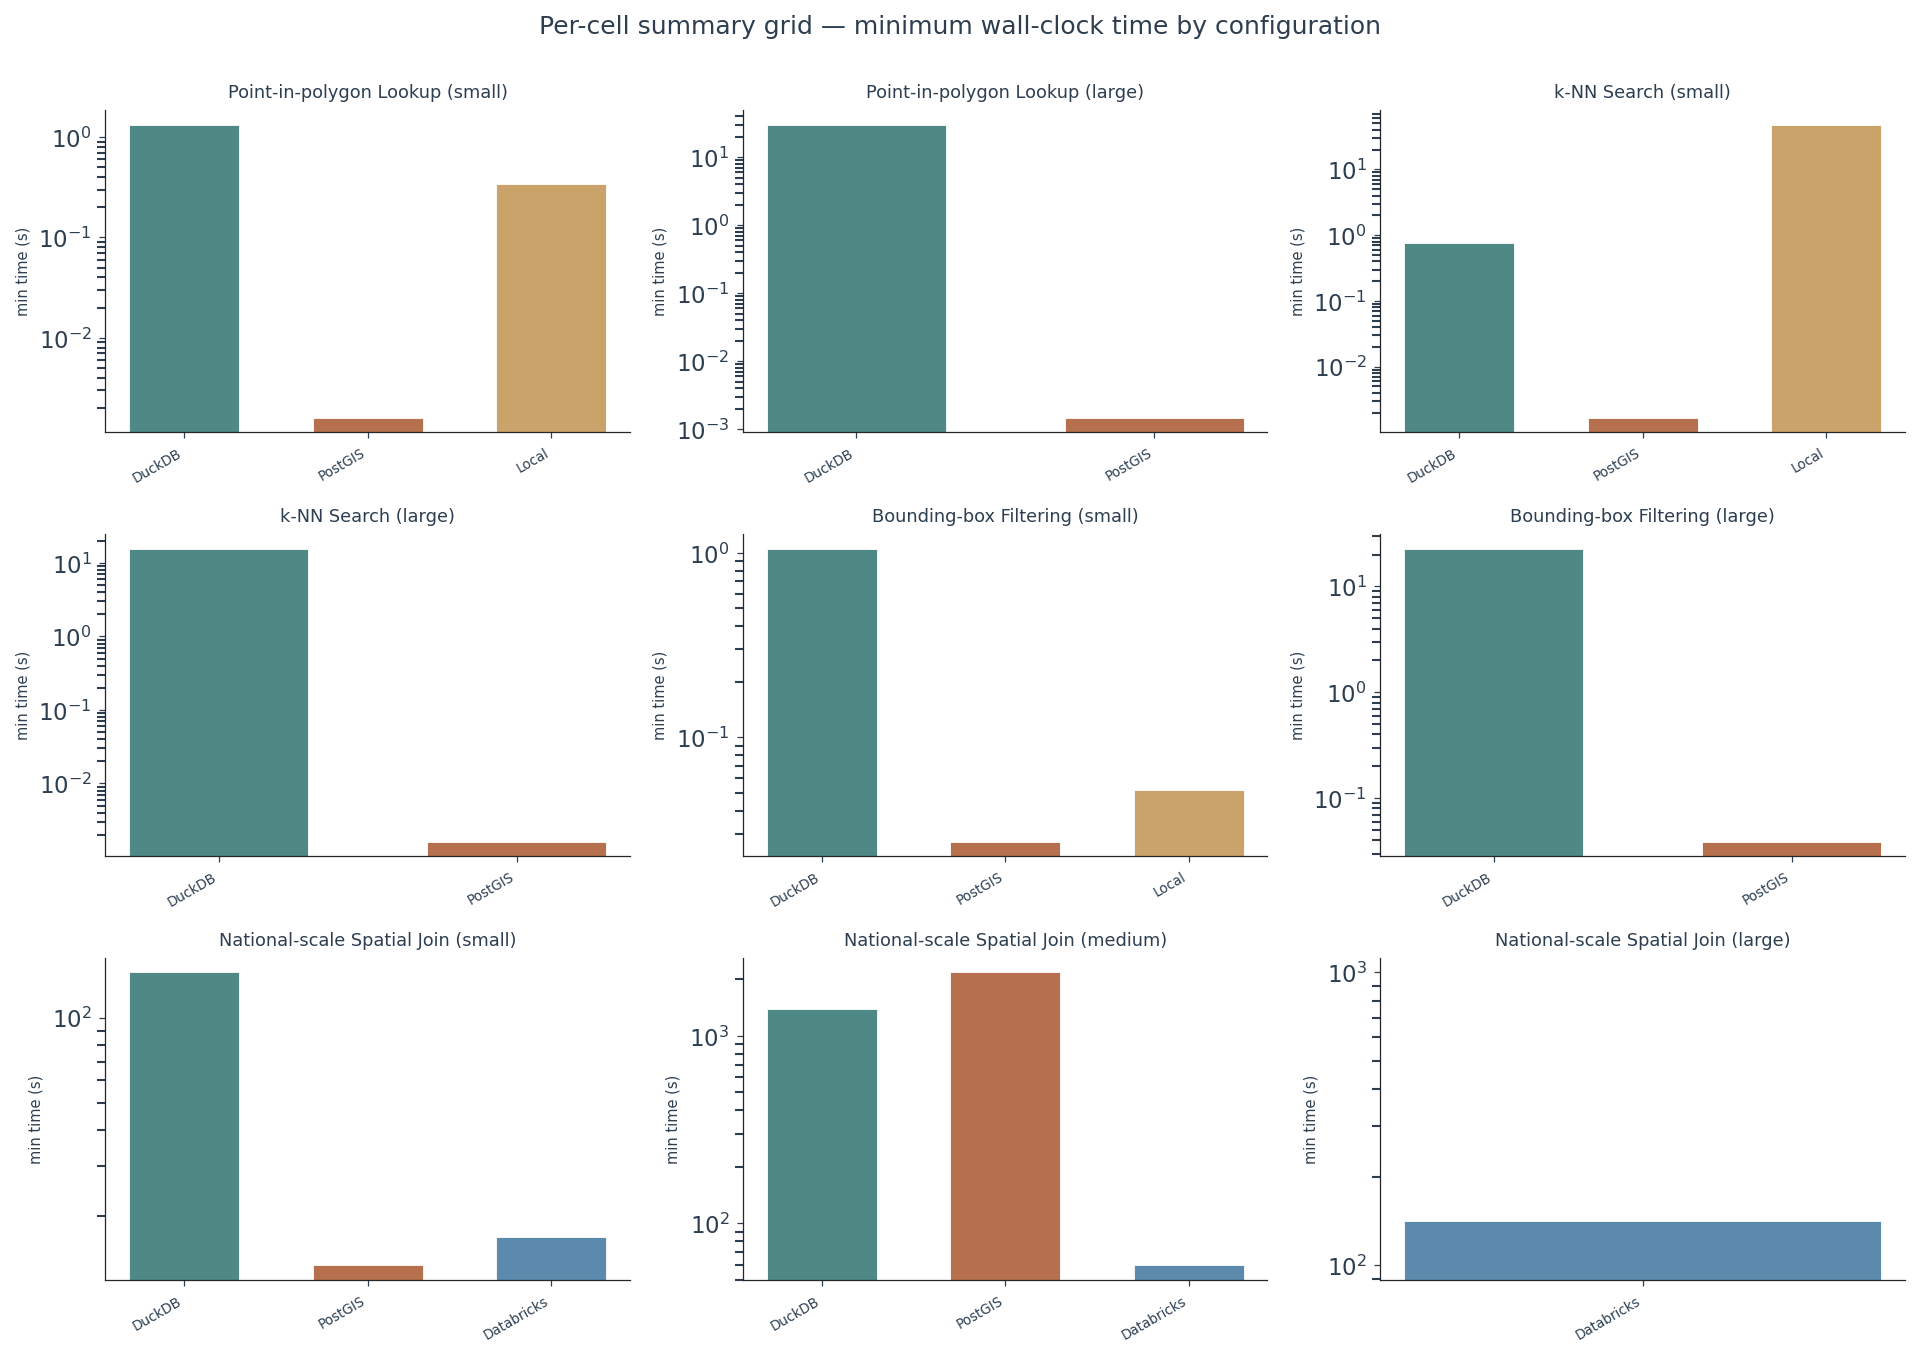

PosixPath('figures/09-cell-grid.png')

In [2]:
tf.fig_cell_grid(successful, cost_summary, cells, allcfg, style, FIG / "09-cell-grid.png")